# Exploratory Data Analysis & Feature Engineering


In [30]:
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns

### Reading the data from csv file



In [31]:
data = pd.read_csv("Telecom Churn Prediction Dataset.csv")
data

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,6840-RESVB,Male,0,Yes,Yes,24,Yes,Yes,DSL,Yes,...,Yes,Yes,Yes,Yes,One year,Yes,Mailed check,84.80,1990.5,No
7039,2234-XADUH,Female,0,Yes,Yes,72,Yes,Yes,Fiber optic,No,...,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.9,No
7040,4801-JZAZL,Female,0,Yes,Yes,11,No,No phone service,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.60,346.45,No
7041,8361-LTMKD,Male,1,Yes,No,4,Yes,Yes,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Mailed check,74.40,306.6,Yes


### Analyzing Data

In [32]:
data.describe() # Gives the statistical analysis

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


In [33]:
data.info() # Gives all the columns and their datatypes

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

In [34]:
#data['TotalCharges']=data["TotalCharges"].astype(float) gives error as there are empty values
(data['TotalCharges']==" ").sum()


np.int64(11)

In [35]:
#So we will deal with these empty values
data["TotalCharges"] = data["TotalCharges"].replace(" ",np.nan)
#Then we fill those  nan values with the median
data['TotalCharges']=data["TotalCharges"].astype(float)
data["TotalCharges"]= data["TotalCharges"].fillna(data["TotalCharges"].median())


In [36]:
# Also converting the "Senior Citizen" column to string as it is categorical
data['SeniorCitizen']=data["SeniorCitizen"].astype(str)

In [37]:
# We can drop  the column "customerID" as it doesnt provide any predictive information
data.drop('customerID',axis=1,inplace=True)
data

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,Male,0,Yes,Yes,24,Yes,Yes,DSL,Yes,No,Yes,Yes,Yes,Yes,One year,Yes,Mailed check,84.80,1990.50,No
7039,Female,0,Yes,Yes,72,Yes,Yes,Fiber optic,No,Yes,Yes,No,Yes,Yes,One year,Yes,Credit card (automatic),103.20,7362.90,No
7040,Female,0,Yes,Yes,11,No,No phone service,DSL,Yes,No,No,No,No,No,Month-to-month,Yes,Electronic check,29.60,346.45,No
7041,Male,1,Yes,No,4,Yes,Yes,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Mailed check,74.40,306.60,Yes


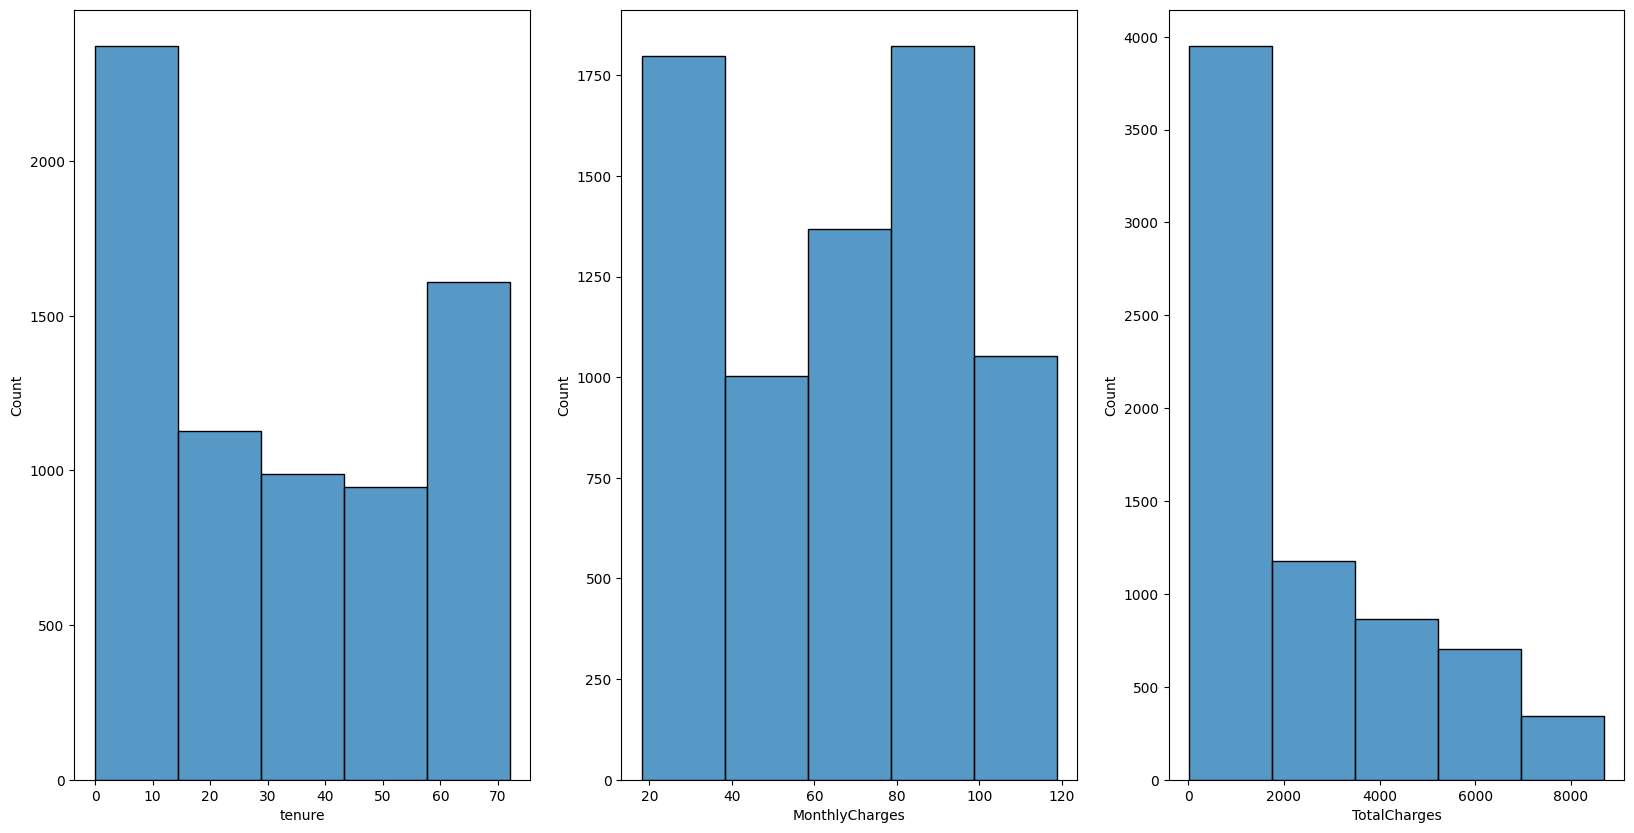

In [38]:
## Checking the distributions using histograms
plt.figure(figsize=(20,10))

plt.subplot (1,3,1)
sns.histplot(data['tenure'],bins=5)
plt.subplot (1,3,2)
sns.histplot(data['MonthlyCharges'],bins=5)
plt.subplot (1,3,3)
sns.histplot(data['TotalCharges'],bins=5);

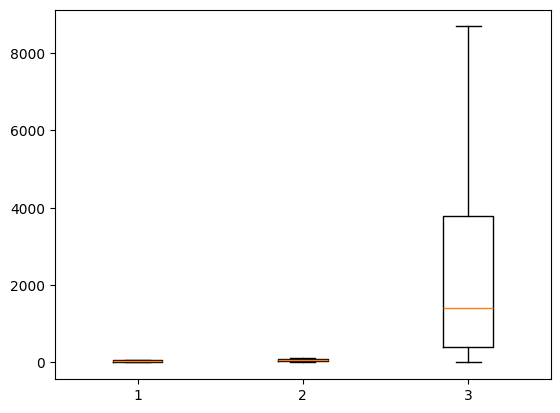

In [39]:
#Checking for outliers
plt.boxplot([data['tenure'],data['MonthlyCharges'],data['TotalCharges']]);


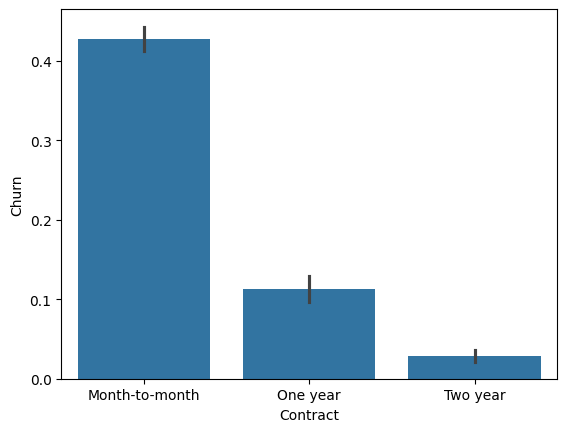

In [40]:
##Churn Rate by contract type
sns.barplot(x='Contract', y='Churn', data=data.assign(Churn=data['Churn'].map({'Yes':1,'No':0})));

In [41]:
##Checking for class imbalance
data["Churn"].value_counts()

Churn
No     5174
Yes    1869
Name: count, dtype: int64

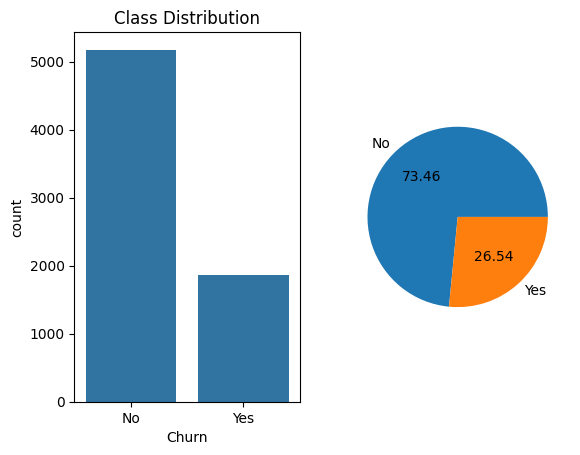

In [42]:
plt.subplot(1,2,1)
sns.countplot(x=data['Churn'])
plt.title("Class Distribution")
plt.subplot(1,2,2)
data["Churn"].value_counts().plot.pie(autopct='%.2f');

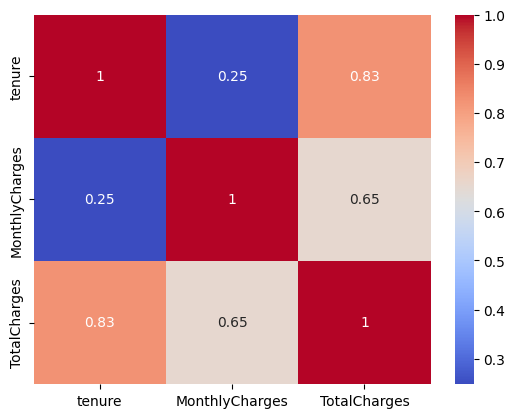

In [43]:
## Checking for correlation between the numerical features
corr = data[['tenure', 'MonthlyCharges', 'TotalCharges']].corr()

sns.heatmap(corr,annot=True,cmap='coolwarm');


#### As we do not have a lot of numerical features so we will not remove any on the basis of correlation

In [44]:
## Checking for unique values in the columns that we doubt
data.columns

Index(['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure',
       'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity',
       'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV',
       'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod',
       'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='str')

In [45]:
cols =['MultipleLines','InternetService','Contract', 'PaymentMethod']
for column in cols:
    print(f"Unique values of {column} are: ",data[column].unique().tolist())
    


Unique values of MultipleLines are:  ['No phone service', 'No', 'Yes']
Unique values of InternetService are:  ['DSL', 'Fiber optic', 'No']
Unique values of Contract are:  ['Month-to-month', 'One year', 'Two year']
Unique values of PaymentMethod are:  ['Electronic check', 'Mailed check', 'Bank transfer (automatic)', 'Credit card (automatic)']


In [46]:
# Checking if our data contains any null values
data.isna().sum()

gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

### Transforming the Columns in Order to Feed them into The Model Later

In [47]:
num_cols = [column for column in data.columns if data[column].dtype != "str"]
cat_cols = data.select_dtypes(include='str').columns.drop("Churn")

In [48]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler,LabelEncoder


transformer = ColumnTransformer(transformers=[("num", StandardScaler(), num_cols),("cat", OneHotEncoder(), cat_cols)])


### Splitting the data for testing and training

In [49]:
from sklearn.model_selection import train_test_split
X= data.drop('Churn',axis=1)
y= data['Churn']
X_train, X_test, y_train,y_test = train_test_split(X,y,test_size=0.25,random_state=32)
X_train = transformer.fit_transform(X_train)
X_test = transformer.transform(X_test)
le = LabelEncoder()
y_train= le.fit_transform(y_train)
y_test = le.transform(y_test)

In [50]:
from imblearn.over_sampling import SMOTE
X_train,y_train = SMOTE(random_state=42).fit_resample(X_train,y_train)

<Axes: ylabel='count'>

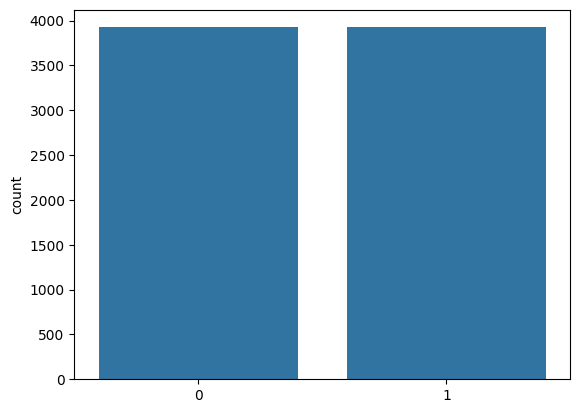

In [51]:
sns.countplot(x=y_train)

### In this way we have obtained a balanced training data

### Now we will put this data into csv files so that we can later use for model training


In [52]:
cols = transformer.get_feature_names_out()


pd.DataFrame(X_train,columns=cols).to_csv('X_train.csv', index=False)
pd.DataFrame(X_test,columns=cols).to_csv('X_test.csv', index=False)
pd.DataFrame(y_train).to_csv('y_train.csv', index=False)
pd.DataFrame(y_test).to_csv('y_test.csv', index=False)

In [53]:
import joblib
joblib.dump(transformer,"transformer.pkl") # To use later in the website

['transformer.pkl']